# B4222 Project Source Code

# Import Libraries

In [2]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import make_scorer, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc, mean_squared_error, RocCurveDisplay

from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# connect google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [4]:
# load dataset
train_df = pd.read_csv("/content/drive/MyDrive/BT4222/Project/data/train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/BT4222/Project/data/test.csv")
sample_submission_df = pd.read_csv("/content/drive/MyDrive/BT4222/Project/data/sample_submission.csv")

# make copy of dataset -> prevent modifying original dataset
train_df = train_df.copy()
test_df = test_df.copy()

# Data Inspection

In [ ]:
# display training dataset -> to understand its structure
train_df.head()

,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,lang,location,profile_background_image_url,profile_image_url,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,target
0,2012-01-15 23:40:09,True,False,Cosplayer/Fitness lover. Come to me https://t....,74,7,0,False,465096524,en,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/9666745212...,reml5477,20,False,0.006,3138,1
1,2016-10-04 00:44:39,False,False,pobody’s nerfect,50443,164,590,True,783105517673648132,cy,she/her,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1281752126...,kinlibra,6469,False,4.572,1415,0
2,2009-05-23 04:04:13,False,False,gracias por participar 🏅,9394,208,189,False,41970759,es,La diaspora,http://abs.twimg.com/images/themes/theme17/bg.gif,http://pbs.twimg.com/profile_images/1233811596...,_delaualau,30296,False,7.378,4106,0
3,2009-05-17 04:31:31,False,False,Stand Up Comedian/Actor from North Philadelphi...,46,66180,1090,True,40607946,en,"Calabasas, CA",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1184851104...,SpankHorton,164957,False,40.116,4112,0
4,2009-02-16 13:11:21,True,False,Assignment Editor at NBC10 and President of Ja...,1223,487,867,True,20983433,en,"Jenkintown, PA",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/5234863934...,javelinjt,1752,False,0.417,4201,0


In [ ]:
# display information of training dataset
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26206 entries, 0 to 26205
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   created_at                    26206 non-null  object 
 1   default_profile               26206 non-null  bool   
 2   default_profile_image         26206 non-null  bool   
 3   description                   21115 non-null  object 
 4   favourites_count              26206 non-null  int64  
 5   followers_count               26206 non-null  int64  
 6   friends_count                 26206 non-null  int64  
 7   geo_enabled                   26206 non-null  bool   
 8   id                            26206 non-null  int64  
 9   lang                          20618 non-null  object 
 10  location                      26204 non-null  object 
 11  profile_background_image_url  22971 non-null  object 
 12  profile_image_url             26205 non-null  object 
 13  s

Observation:
- Numeric columns:  `favourites_count`, `followers_count`, `friends_count`, `id`, `statuses_count`, `average_tweets_per_day`, `account_age_days`
- Boolean columns: `default_profile`, `default_profile_image`, `geo_enabled`, `verified`
- Object columns: `created_at`, `description`, `lang`, `location`, `profile_background_image_url`, `profile_image_url`, `screen_name`
- Target column: `target`

In [ ]:
# for numeric columns, display descriptive statistics of training dataset
train_df.describe()

,favourites_count,followers_count,friends_count,id,statuses_count,average_tweets_per_day,account_age_days,target
count,26206.000000,2.620600e+04,2.620600e+04,2.620600e+04,2.620600e+04,26206.000000,26206.000000,26206.000000
mean,12159.971342,3.732983e+05,4.427275e+03,1.253306e+17,2.072485e+04,6.754636,3017.870831,0.335152
std,33628.948536,2.515996e+06,4.602204e+04,3.035728e+17,6.345569e+04,22.782745,1018.958572,0.472053
min,0.000000,0.000000e+00,0.000000e+00,5.860000e+02,0.000000e+00,0.000000,483.000000,0.000000
25%,347.000000,3.400000e+01,3.400000e+01,9.799366e+07,1.331000e+03,0.486250,2302.000000,0.000000
50%,2037.000000,3.540000e+02,2.920000e+02,3.997210e+08,4.143500e+03,1.464000,3218.000000,0.000000
75%,8751.750000,8.241500e+03,8.780000e+02,2.480241e+09,1.679150e+04,5.460000,3895.000000,1.000000
max,839929.000000,1.216415e+08,1.641962e+06,1.120974e+18,2.771910e+06,1191.286000,5151.000000,1.000000


In [ ]:
# for categorical columns, display unique values of training dataset

# select categorical columns
cat_cols = train_df.select_dtypes(include="object").columns

# count unique values in each categorical columns
pd.DataFrame({
    "non_null_count": train_df[cat_cols].count(),
    "unique_values_excluding_null": train_df[cat_cols].nunique(),
    "unique_values_including_null": train_df[cat_cols].nunique(dropna=False)
})

,non_null_count,unique_values_excluding_null,unique_values_including_null
created_at,26206,26205,26205
description,21115,20988,20989
lang,20618,48,49
location,26204,8884,8885
profile_background_image_url,22971,20,21
profile_image_url,26205,25820,25821
screen_name,26206,26206,26206


Observation:

`created_at`, `description`, `profile_image_url` and `screen_name` has similar counts for non-null values and unique values, indicating that almost every non-null entry in these columns is distinct, so these features exhibit high cardinality and are unlikely to provide meaningful patterns for predictive modeling since their values do not repeat across observations.

In [ ]:
# for categorical columns, display unique values of training dataset (continuation)

# further investigation on whether `profile_background_image_url` is a meaningful feature
train_df.groupby("profile_background_image_url")["target"].agg(
    total_count="count",
    target_1_count="sum"
)

,total_count,target_1_count
profile_background_image_url,,
http://abs.twimg.com/images/themes/theme1/bg.png,15171,5707
http://abs.twimg.com/images/themes/theme10/bg.gif,651,139
http://abs.twimg.com/images/themes/theme11/bg.gif,338,65
http://abs.twimg.com/images/themes/theme12/bg.gif,191,43
http://abs.twimg.com/images/themes/theme13/bg.gif,224,56
http://abs.twimg.com/images/themes/theme14/bg.gif,1611,271
http://abs.twimg.com/images/themes/theme15/bg.png,585,96
http://abs.twimg.com/images/themes/theme16/bg.gif,186,38
http://abs.twimg.com/images/themes/theme17/bg.gif,210,35


Observation:

For each unique `profile_background_image_url`, the difference between the total number of observations and number of cases where target = 1 is considerably large, suggesting that `profile_background_image_url` likely does not exhibit a meaningful relationship with the target variable, and is unlikely to contribute significant predictive value to the model.

In [ ]:
# for categorical columns, display unique values of training dataset (continuation)

# get unique values for useful categorical columns
useful_cat_cols = ["lang", "location"]

for col in useful_cat_cols:
  print(f"{col}: ")
  print(f"categories: {train_df[col].unique()}")
  print(f"number of categories: {len(train_df[col].unique())}")

lang: 
categories: ['en' 'cy' 'es' nan 'pt' 'ar' 'fr' 'de' 'sw' 'sl' 'da' 'lt' 'it' 'nl' 'ja'
 'ca' 'ro' 'ru' 'cs' 'el' 'tr' 'id' 'af' 'vi' 'tl' 'sq' 'pl' 'sv' 'so'
 'zh-cn' 'bg' 'fi' 'hr' 'et' 'no' 'hu' 'th' 'ko' 'mk' 'sk' 'ur' 'uk' 'fa'
 'lv' 'ne' 'hi' 'pa' 'zh-tw' 'he']
number of categories: 49
location: 
categories: ['unknown' 'she/her ' 'La diaspora' ... 'YALOVA,Türkiye' 'S ❣️'
 'Eating, sleeping, & exploring']
number of categories: 8885


In [ ]:
# display test dataset -> to understand its structure
test_df.head()

,index,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,lang,location,profile_background_image_url,profile_image_url,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days
0,0,2007-03-27 22:56:04,False,False,Dad. #ADHD @fasternormal Pod host. Author/keyn...,22290,163813,1746,True,2569261,en,"New York, NY",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1186468889...,petershankman,42013,True,8.586,4893
1,1,2013-03-30 08:47:01,True,False,NaN,685,44,637,False,1316038452,NaN,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/9637876928...,Mihail_HD,111,False,0.041,2699
2,2,2009-04-25 15:24:08,False,False,#UGAMOM #GODAWGS,12257,276,194,True,35233977,de,"Augusta, GA",http://abs.twimg.com/images/themes/theme3/bg.gif,http://pbs.twimg.com/profile_images/1246470377...,TinkerMazell,18142,False,4.390,4133
3,3,2010-08-06 22:21:56,True,False,"golfer, traveler, car guy, PCA member, owns 19...",30806,1124,4999,True,175542625,en,New York,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1391357162...,joecangolfICC,20624,False,5.627,3665
4,4,2015-03-02 12:29:39,True,False,Do you like it gently? Come in! 💚💚💚 https://t....,224,22,265,False,3056068536,en,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/9680856906...,TiesiogDovydas,64,False,0.032,1996


Observation:

Test dataset has no `target` variable, which means the column we are trying to predict is missing (no label), so we cannot use it to test the accuracy of our ML model, can only use it for prediction.

## Split Data

As test dataset has no `target` variable, we need another test dataset to test our trained models.

In [5]:
X = train_df.drop(columns=["target"])
y = train_df["target"]

# split train data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=4222)
print(f"Training set: \nX: {X_train.shape} \ny: {y_train.shape} \nsamples: {len(X_train)} \nfeatures: {X_train.shape[1]}")
print("===================")
print(f"Test set: \nX: {X_test.shape} \ny: {y_test.shape} \nsamples: {len(X_test)} \nfeatures: {X_test.shape[1]}")

# reset index of X_train, X_test, y_train, y_test
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

Training set: 
X: (19654, 18) 
y: (19654,) 
samples: 19654 
features: 18
Test set: 
X: (6552, 18) 
y: (6552,) 
samples: 6552 
features: 18


## Check for imbalanced dataset

Target Distribution: 
 target
0    17423
1     8783
Name: count, dtype: int64
Target Distribution (%): 
 target
0    0.664848
1    0.335152
Name: proportion, dtype: float64


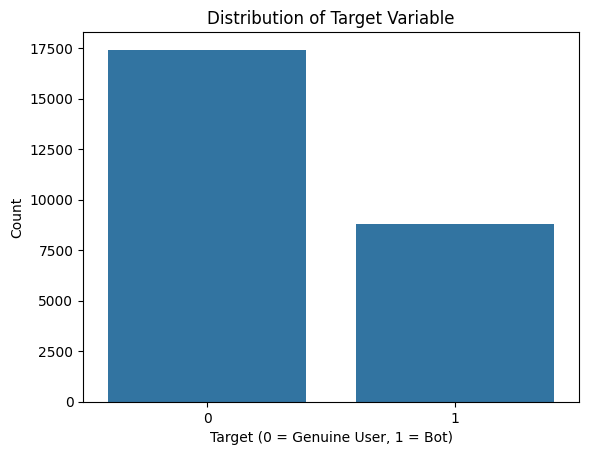

In [ ]:
# check distribution of target variable for training dataset
target_counts = train_df["target"].value_counts()
print("Target Distribution: \n", target_counts)

target_counts_percentage = train_df["target"].value_counts(normalize=True)
print("Target Distribution (%): \n", target_counts_percentage)

# visualize distribution
sns.countplot(data=train_df, x="target")
plt.title("Distribution of Target Variable")
plt.xlabel("Target (0 = Genuine User, 1 = Bot)")
plt.ylabel("Count")
plt.show()

Observation:

Data is slightly imbalanced with more genuine users and less bots, increasing the risk of overfitting, but not to a problematic level.

[XGBoost (uses regularization to prevent overfitting) likely covers it]

# Data Cleaning

Only for training set (X_train, y_train) to prevent data leakage

## Duplicated row

In [ ]:
# check for duplicated rows
duplicates_train = X_train.duplicated()
num_duplicates_train = duplicates_train.sum()

print(f"Number of duplicated rows: {num_duplicates_train}")

Number of duplicated rows: 0


Observation:

No duplicated rows were found.

## Missing values

Upon earlier inspection, there are several fields with null values and these fields are all categorical. The missing data likely means the information is unavailable or not applicable. Thus, fill in an appropriate categorical value, "Unknown", to preserve the understanding that the data may exist but is not provided.

In [6]:
# check for missing values in training dataset
missing_values_train = X_train.isnull().sum()
missing_values_train = missing_values_train[missing_values_train > 0]
print("Missing Values in Training Dataset: \n", missing_values_train)

Missing Values in Training Dataset: 
 description                     3821
lang                            4194
location                           2
profile_background_image_url    2427
profile_image_url                  1
dtype: int64


In [7]:
# impute missing values in training dataset
X_train["description"] = X_train["description"].fillna("unknown")
X_train["lang"] = X_train["lang"].fillna("unknown")
X_train["location"] = X_train["location"].fillna("unknown")
X_train["profile_background_image_url"] = X_train["profile_background_image_url"].fillna("unknown")
X_train["profile_image_url"] = X_train["profile_image_url"].fillna("unknown")

In [8]:
# verify no missing values in training dataset
if X_train.isnull().sum().sum() == 0:
  print("No missing values in training dataset")
else:
  missing_values_train = X_train.isnull().sum()
  missing_values_train = missing_values_train[missing_values_train > 0]
  print("Missing Values in Training Dataset: \n", missing_values_train)

No missing values in training dataset


# Outlier Detection

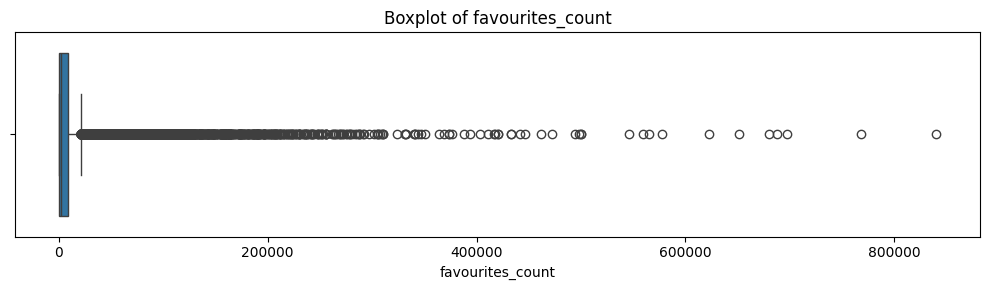

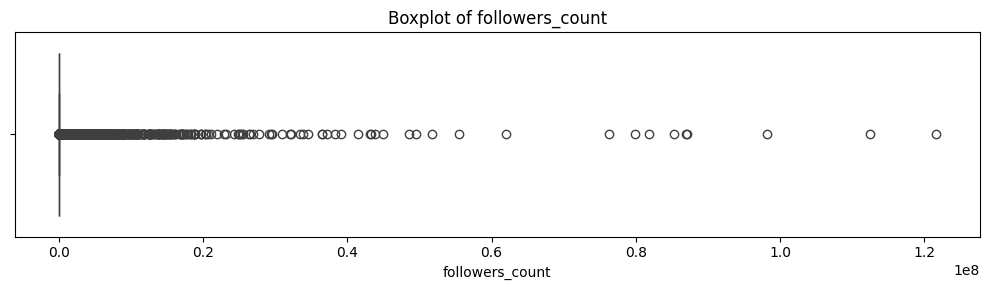

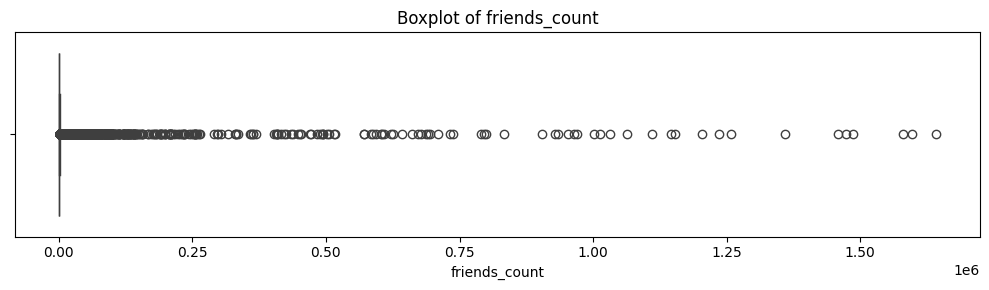

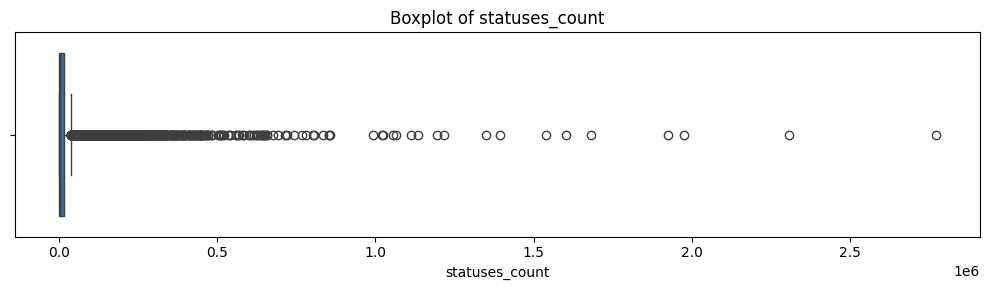

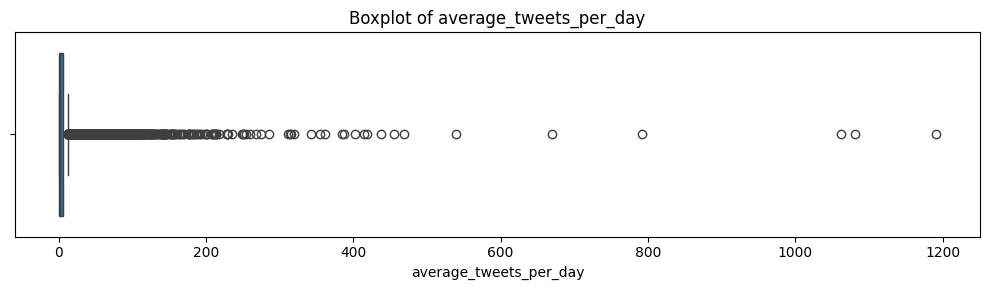

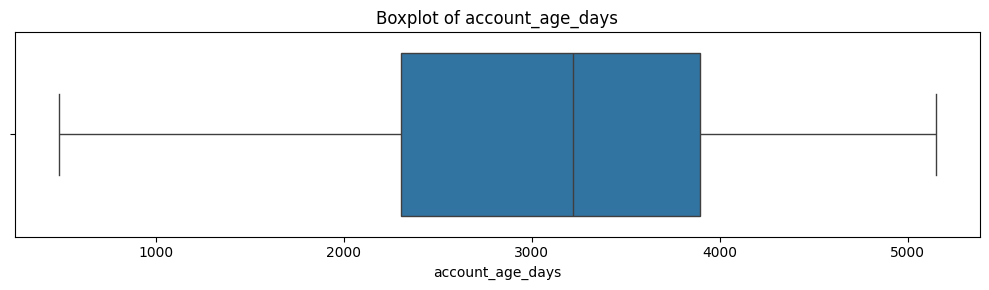

In [ ]:
# use boxplot to detect outliers in training dataset

# select numerical columns
num_cols = X_train.select_dtypes(include=["int64", "float64"]).drop(columns=["id"]).columns

# create boxplots
for i, col in enumerate(num_cols, 1):
  plt.figure(figsize=(10, 3))
  sns.boxplot(x=train_df[col])
  plt.title(f"Boxplot of {col}")
  plt.tight_layout() # prevent overlap

plt.show()


# Correlation Analysis

<Axes: >

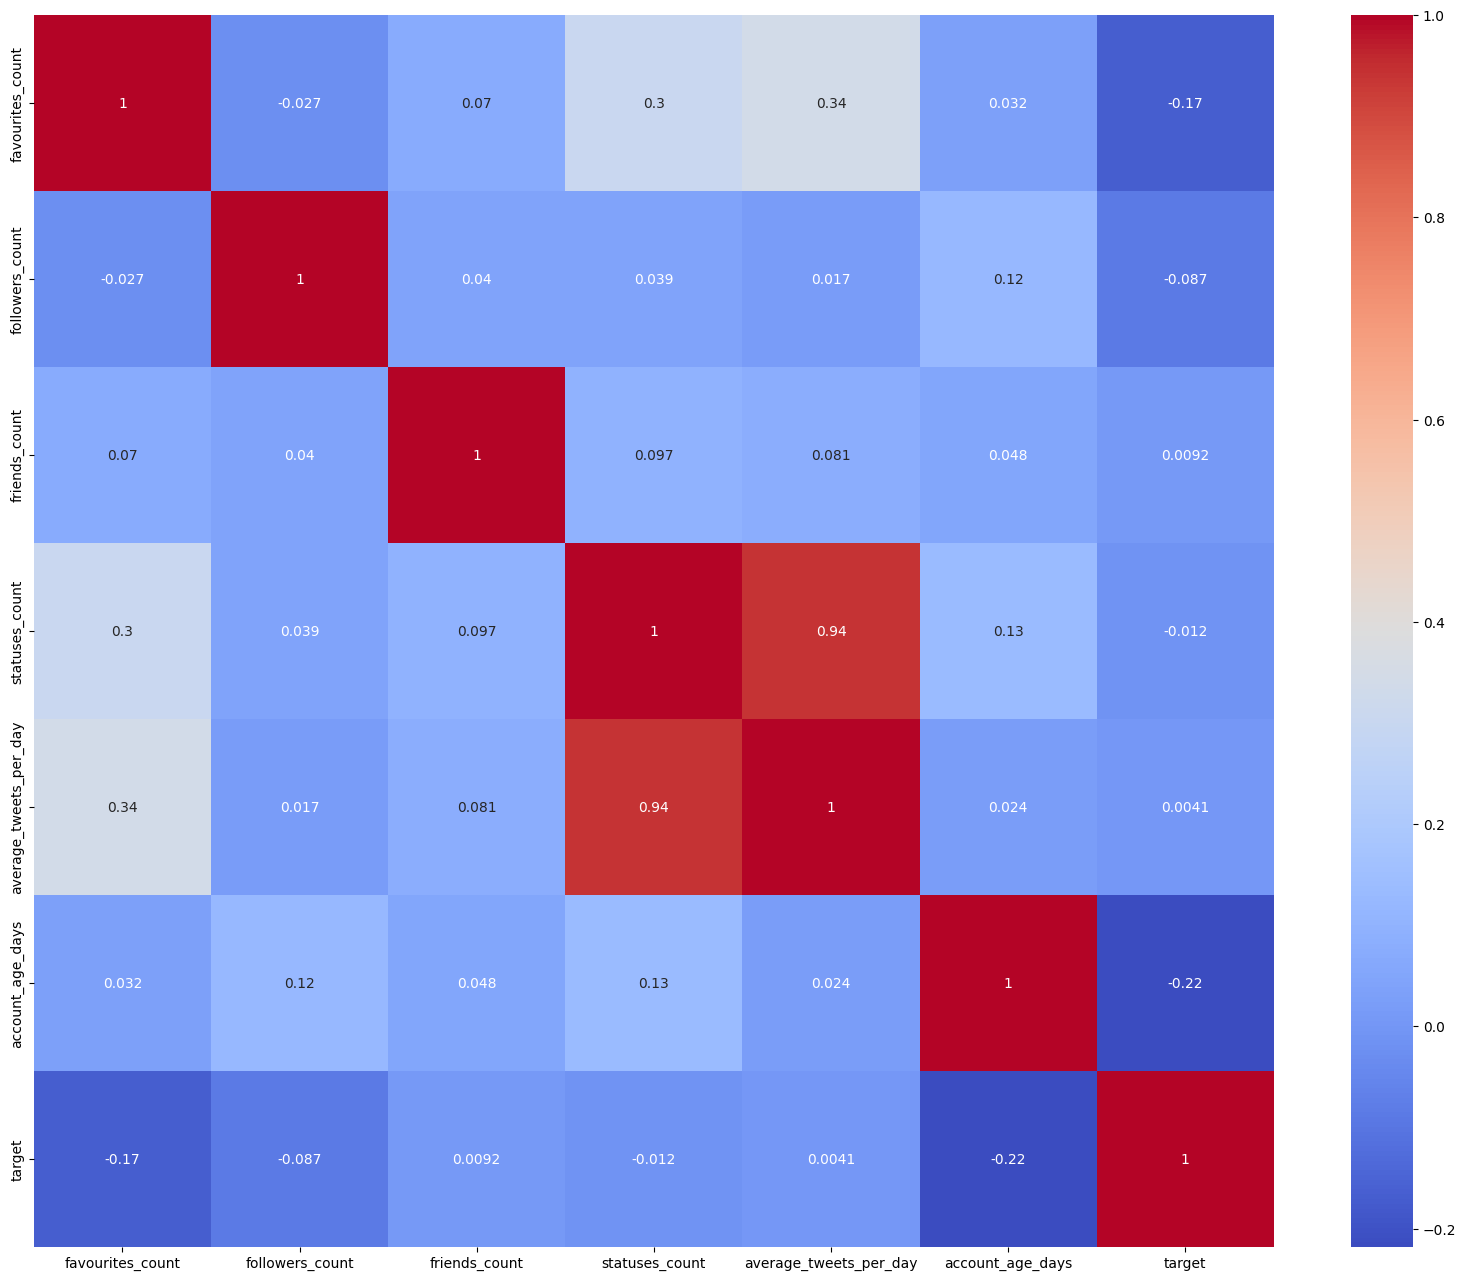

In [ ]:
# use correlation matrix to do correlation analysis of training dataset

# select numerical columns
feature_cols = X_train.select_dtypes(include=["int64", "float64"]).drop(columns=["id"]).columns
target_col = y_train
corr_df = pd.concat([X_train[feature_cols], target_col], axis=1)
correlation = corr_df.corr()

# create correlation matrix
plt.figure(figsize=(20, 16))
sns.heatmap(correlation, annot=True, cmap="coolwarm")

# Feature Engineering

## Creating Features

- favourites -> tweets user liked
- followers -> accounts following user
- friends -> accounts user follow
- status -> tweets user posted

Consider:
* Engagement Ratios
  * followers to friends ratio
  * difference between number of followers and number of friends
  * tweets (statuses) to followers ratio
  * favourites to followers ratio
  * favourites to friends ratio
* Normalized Activity Ratios
  * follower growth rate per day
  * friends growth rate per day (following growth rate per day)
  * tweets (statuses) growth rate per day (posting frequency)
  * favourites growth rate per day (liking activity)
* Social Activity Rates
  * number of tweets per friends
  * number of likes per friends
  * number of likes per tweet
* Account Characteristics
  * high tweet frequency but low followers -> measures whether account tweets agressively but fail to attract followers
  * high tweet frequency but low account age -> measures whether newly created account tweets agressively
* Account age categories -> categorize accounts by age (very new, new, established, old)
* Profile completeness
  * uses default profile and image
  * has profile image
  * has background image
* Screen name patterns
  * length of username
  * digit to characters ratio in screen name
  * special characters to characters ratio in screen name
* Description Patterns
  * length of description
  * number of words in description
  * digit to characters ratio in description
  * number of special characters in description
  * uppercase to characters ratio in description
* Tweet patterns
  * number of tweets per day relative to age
* Temporal Patterns
  * new (age < 1yr) and verified
  * quite new (age < 90 days) and high tweet (statuses)
  * quite new (age < 90 days) and high tweet frequency
  * quite new (age < 90 days) and high favourites
* Suspicious Behaviour Flags
  * has url in description
  * has url in screen name
  * has spam words in description




In [9]:
# engagement ratios
X_train["followers_friends_ratio"] = X_train["followers_count"] / (X_train["friends_count"] + 1e-5)
X_train["follower_friend_disparity"] = abs(X_train["followers_count"] - X_train["friends_count"])
X_train["tweets_followers_ratio"] = X_train["statuses_count"] / (X_train["followers_count"] + 1e-5)
X_train["favourites_followers_ratio"] = X_train["favourites_count"] / (X_train["followers_count"] + 1e-5)
X_train["favourites_friends_ratio"] = X_train["favourites_count"] / (X_train["friends_count"] + 1e-5)

# normalized activity rates
X_train["normalized_followers"] = X_train["followers_count"] / (X_train["account_age_days"] + 1e-5)
X_train["normalized_friends"] = X_train["friends_count"] / (X_train["account_age_days"] + 1e-5)
X_train["normalized_tweets"] = X_train["statuses_count"] / (X_train["account_age_days"] + 1e-5)
X_train["normalized_favourites"] = X_train["favourites_count"] / (X_train["account_age_days"] + 1e-5)

# social activity ratios
X_train["tweets_per_friends"] = X_train["statuses_count"] / (X_train["friends_count"] + 1e-5)
X_train["likes_per_friends"] = X_train["favourites_count"] / (X_train["friends_count"] + 1e-5)
X_train["likes_per_tweet"] = X_train["favourites_count"] / (X_train["statuses_count"] + 1e-5)

Purpose of adding 1e-5 to denominator is to prevent division by 0, but also ensure it barely changes the value of the denominator [numerical stability trick]

-> if denominator = 0, ratio becomes extremely large, which may skew distribution and create extreme outliers, thus hurting model performance

In [10]:
# account characteristics
high_tweets_freq_threshold = X_train['average_tweets_per_day'].quantile(0.90) # 90th percentile for high tweet frequency
low_followers_threshold = X_train['followers_count'].quantile(0.10) # 10th percentile for low followers
X_train['high_tweet_freq_low_follower'] = ((X_train['average_tweets_per_day'] > high_tweets_freq_threshold)
                                        & (X_train['followers_count'] < low_followers_threshold)).astype(int)

high_tweets_freq_threshold = X_train["average_tweets_per_day"].quantile(0.90)  # 90th percentile for high tweet frequency
low_age_threshold = 365  # 1 year (365 days) for low account age
X_train["high_tweet_freq_low_age"] = ((X_train["average_tweets_per_day"] > high_tweets_freq_threshold)
                                    & (X_train["account_age_days"] < low_age_threshold)).astype(int)

# account age categories
X_train["account_age_category"] = pd.cut(
    X_train["account_age_days"],
    bins=[0, 365, 730, 1825, float("inf")],
    labels=["Very New", "New", "Established", "Old"]
).cat.codes

# profile completeness
X_train["default_profile_and_image"] = ((X_train["default_profile"] == 1) &
                                         (X_train["default_profile_image"] == 1)).astype(int)
X_train["has_profile_image"] = (X_train["profile_image_url"] != "unknown").astype(int)
X_train["has_background_image"] = (X_train["profile_background_image_url"] != "unknown").astype(int)

# screen name patterns
X_train["username_length"] = X_train["screen_name"].apply(lambda x: len(x))
X_train["username_digit_ratio"] = X_train["screen_name"].apply(lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0)
X_train["username_special_chars_ratio"] = X_train["screen_name"].apply(lambda x: sum(1 for c in x if not c.isalnum()) / len(x) if len(x) > 0 else 0) # .isalnum checks whether character is an alphabet or number (alphanumeric)

# description patterns
X_train["has_description"] = (X_train["description"] != "unknown").astype(int)
X_train["description_length"] = X_train["description"].apply(lambda x: len(x))
X_train["description_word_count"] = X_train["description"].apply(lambda x: len(x.split()))
X_train["description_digit_ratio"] = X_train["description"].apply(lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0)
X_train["description_special_chars_count"] = X_train["description"].apply(lambda x: sum(1 for c in x if c in "!@#$%^&*") if isinstance(x, str) else 0)
X_train["description_uppercase_ratio"] = X_train["description"].apply(lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0)

# tweet patterns
X_train["tweets_freq_relative_to_age"] = X_train["average_tweets_per_day"] / (X_train["account_age_days"] + 1e-5)

# temporal patterns
X_train["is_new_with_verified"] = ((X_train["account_age_days"] < 365) & (X_train["verified"] == 1)).astype(int)
X_train["is_recently_active_high_tweets"] = ((X_train["account_age_days"] < 90) & (X_train["statuses_count"] > 500)).astype(int)

high_tweets_freq_threshold = X_train["average_tweets_per_day"].quantile(0.90) # 90th percentile for high tweet frequency
X_train["is_recently_active_high_tweets_freq"] = ((X_train["account_age_days"] < 90) & (X_train["average_tweets_per_day"] > high_tweets_freq_threshold)).astype(int)

high_favourites_threshold = X_train["favourites_count"].quantile(0.90) # 90th percentile for high favourites
X_train["is_recently_active_high_favourites"] = ((X_train["account_age_days"] < 90) & (X_train["favourites_count"] > high_favourites_threshold)).astype(int)

# suspicious behaviour flags
X_train["has_url_in_description"] = X_train["description"].apply(lambda x: int("http" in x or "www" in x))
X_train["has_url_in_username"] = X_train["screen_name"].apply(lambda x: int("http" in x or "www" in x))

## some spam words referenced from https://lix-it.com/blog/spam-trigger-words/#spam
spam_words = [
    'win', 'free', 'offer', 'click', 'buy', 'subscribe',
    'act now', 'apply now', 'call now', 'don’t hesitate',
    'for only', 'get started now', 'limited time', 'great offer',
    'instant', 'now only', 'offer expires', 'once in a lifetime',
    'order now', 'order today', 'special promotion', 'urgent',
    'while supplies last', 'bonus', 'all new', 'amazing',
    'certified', 'congratulations', 'fantastic deal', 'for free',
    'guaranteed', 'outstanding value', 'risk free',
    'satisfaction guaranteed', 'free!', 'free trial', 'free consultation',
    'free gift', 'free membership', 'free offer', 'free preview',
    'free sample', 'free quote', 'sign up free today', 'deal',
    'giving away', 'no obligation', 'no strings attached', 'offer',
    'prize', 'trial', 'unlimited', 'what are you waiting for?',
    'win', 'winner', 'you’re a winner!', 'won', 'you have been selected',
    '#1', '100% free', '100% satisfied', '50% off',
    'one hundred percent guaranteed', 'click below', 'click here',
    'increase sales', 'increase your sales', 'opt in', 'open', 'sale',
    'sales', 'subscribe', 'chance', 'sample', 'satisfaction', 'solution',
    'success', 'cards accepted', 'full refund', 'affordable',
    'bargain', 'best price', 'cash', 'cash bonus', 'cheap',
    'credit', 'discount', 'for just $', 'lowest price', 'save big money',
    'why pay more?', 'buy', 'as seen on', 'buy direct', 'clearance',
    'order', '$$$', 'marketing solutions', 'join millions',
    'name brand', 'no questions asked', 'giving it away',
    'best rates', 'compare', 'drastically reduced'
]

X_train["description_spam_score"] = X_train["description"].apply(lambda x: sum(word in x.lower() for word in spam_words) if isinstance(x, str) else 0)

## Gathering Further Insights

Other insights to consider:
* verified vs target -> check if being verified has any correlation to being a bot account
* account age vs target -> check if age of account has any correlation to being a bot account
* geo-enabled vs target -> check if there is a correlation between enabling location services and bot account
* average tweets per day vs target -> check relationship between tweet frequency and bot account

<Figure size 800x500 with 0 Axes>

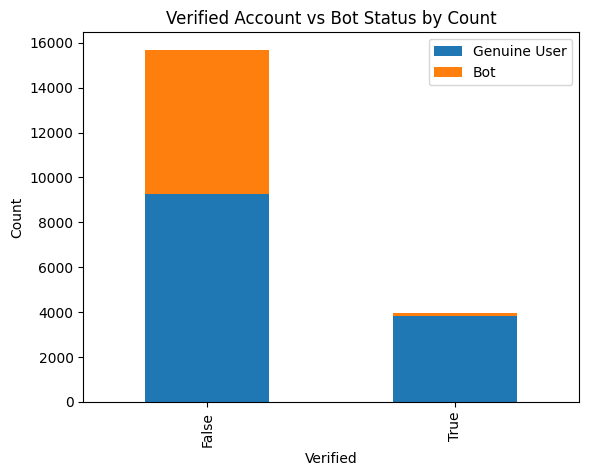

<Figure size 800x500 with 0 Axes>

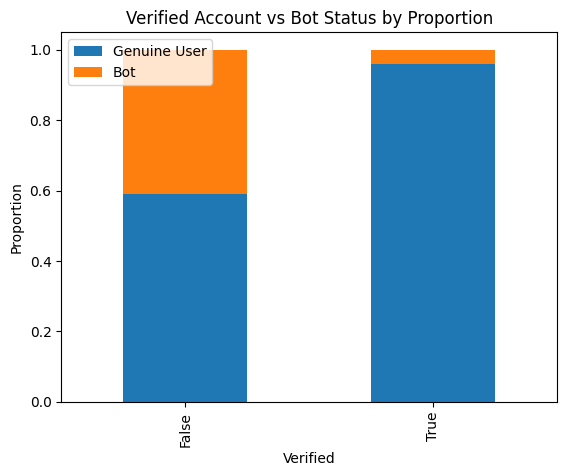

In [ ]:
# verified vs target
train_plot_df = X_train.copy()
train_plot_df["target"] = y_train

verified_counts = train_plot_df.groupby(["verified", "target"]).size().unstack()
verified_proportions = verified_counts.div(verified_counts.sum(axis=1), axis=0)

plt.figure(figsize=(8, 5))
verified_counts.plot(kind="bar", stacked=True)
plt.title("Verified Account vs Bot Status by Count")
plt.xlabel("Verified")
plt.ylabel("Count")
plt.legend(["Genuine User", "Bot"])
plt.show()

plt.figure(figsize=(8, 5))
verified_proportions.plot(kind="bar", stacked=True)
plt.title("Verified Account vs Bot Status by Proportion")
plt.xlabel("Verified")
plt.ylabel("Proportion")
plt.legend(["Genuine User", "Bot"])
plt.show()

Observation:

*  High proportion of verified accounts are genuine users
*  Bot accounts tend to be unverified

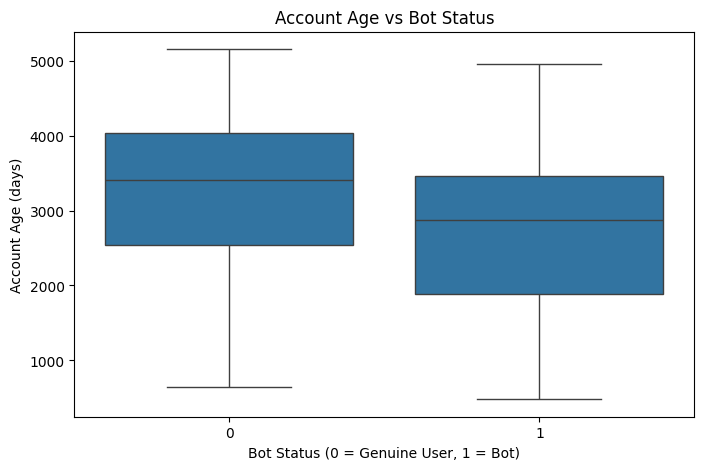

In [ ]:
# account age vs target
train_plot_df = X_train.copy()
train_plot_df["target"] = y_train

plt.figure(figsize=(8, 5))
sns.boxplot(x="target", y="account_age_days", data=train_plot_df)
plt.title("Account Age vs Bot Status")
plt.xlabel("Bot Status (0 = Genuine User, 1 = Bot)")
plt.ylabel("Account Age (days)")
plt.show()

Observation:

*  Comparatively, genuine users tend to be have older accounts, while bots tend to have younger accounts

<Figure size 800x500 with 0 Axes>

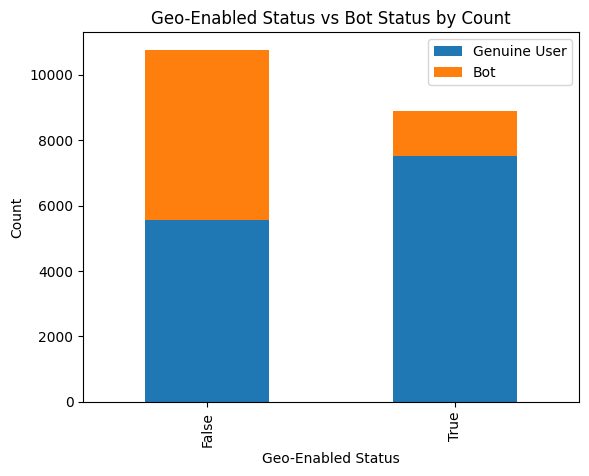

<Figure size 800x500 with 0 Axes>

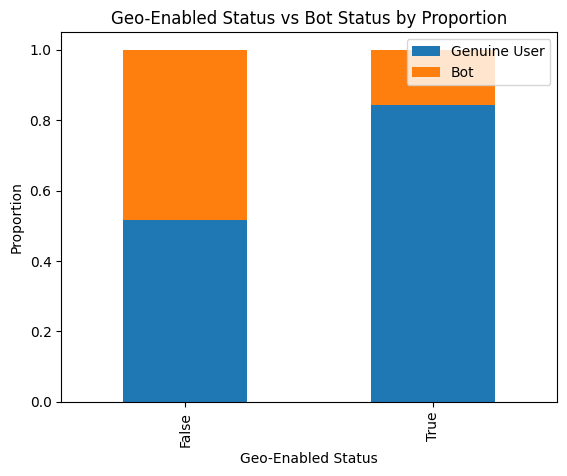

In [ ]:
# geo_enabled vs target
train_plot_df = X_train.copy()
train_plot_df["target"] = y_train

geo_enabled_counts = train_plot_df.groupby(["geo_enabled", "target"]).size().unstack()
geo_enabled_proportions = geo_enabled_counts.div(geo_enabled_counts.sum(axis=1), axis=0)

plt.figure(figsize=(8, 5))
geo_enabled_counts.plot(kind="bar", stacked=True)
plt.title("Geo-Enabled Status vs Bot Status by Count")
plt.xlabel("Geo-Enabled Status")
plt.ylabel("Count")
plt.legend(["Genuine User", "Bot"])
plt.show()

plt.figure(figsize=(8, 5))
geo_enabled_proportions.plot(kind="bar", stacked=True)
plt.title("Geo-Enabled Status vs Bot Status by Proportion")
plt.xlabel("Geo-Enabled Status")
plt.ylabel("Proportion")
plt.legend(["Genuine User", "Bot"])
plt.show()

Observation:

*  Bot accounts tend to not be geo-enabled

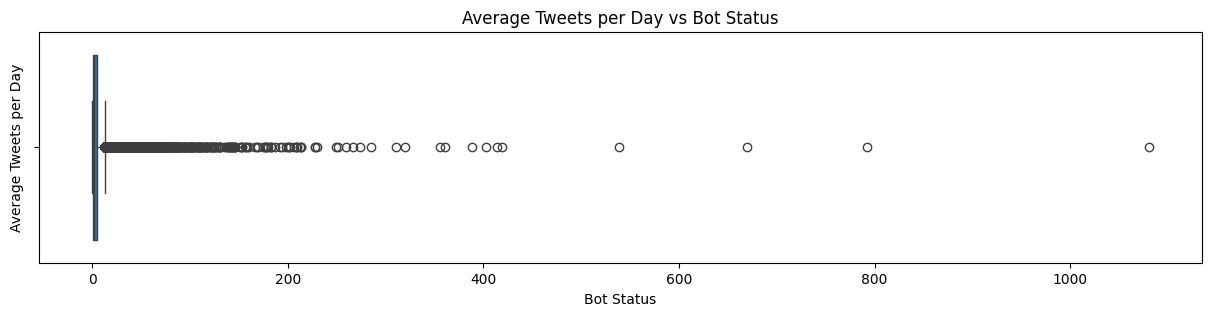

In [ ]:
# average tweets per day vs target
plt.figure(figsize=(15, 3))
sns.boxplot(x=X_train["average_tweets_per_day"])
plt.title("Average Tweets per Day vs Bot Status")
plt.xlabel("Bot Status")
plt.ylabel("Average Tweets per Day")
plt.show()

## Encode Categorical Features

### Label Encoding

In [11]:
# label encoding of binary features
# initialise LabelEncoder
label_encoder = LabelEncoder() # converts categorical text/bool features into numeric labels (False/No -> 0; True/Yes -> 1)

# for training data -> use .fit_transform()
X_train["default_profile_le"] = label_encoder.fit_transform(X_train["default_profile"])
X_train["default_profile_image_le"] = label_encoder.fit_transform(X_train["default_profile_image"])
X_train["geo_enabled_le"] = label_encoder.fit_transform(X_train["geo_enabled"])
X_train["verified_le"] = label_encoder.fit_transform(X_train["verified"])

# label encoding of multi-class categorical features
# for training data
X_train["lang"] = pd.Categorical(X_train["lang"]) # define categories -> by converting `lang` to pandas categorical type
lang_categories = X_train["lang"].cat.categories # stores list of all categories
X_train["lang"] = X_train["lang"].cat.codes # convert categories to integer codes -> each category gets a unique integer

### Textual preprocessing
refer to version2

### One-hot Encoding

refer to final

## Sentiment analysis

refer to final

## Result

In [12]:
print(f"Training set: \nX: {X_train.shape} \ny: {y_train.shape} \nsamples: {len(X_train)} \nfeatures: {X_train.shape[1]} \n")

X_train.info()

Training set: 
X: (19654, 57) 
y: (19654,) 
samples: 19654 
features: 57 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19654 entries, 0 to 19653
Data columns (total 57 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   created_at                           19654 non-null  object 
 1   default_profile                      19654 non-null  bool   
 2   default_profile_image                19654 non-null  bool   
 3   description                          19654 non-null  object 
 4   favourites_count                     19654 non-null  int64  
 5   followers_count                      19654 non-null  int64  
 6   friends_count                        19654 non-null  int64  
 7   geo_enabled                          19654 non-null  bool   
 8   id                                   19654 non-null  int64  
 9   lang                                 19654 non-null  int8   
 10  location           

# Model Prediction

## Prepare Test Data

Apply fitted transformations on training data to test data

In [13]:
# data cleaning of test dataset
def clean_test(X_test):
  # impute missing values in test dataset
  X_test["description"] = X_test["description"].fillna("unknown")
  X_test["lang"] = X_test["lang"].fillna("unknown")
  X_test["location"] = X_test["location"].fillna("unknown")
  X_test["profile_background_image_url"] = X_test["profile_background_image_url"].fillna("unknown")
  X_test["profile_image_url"] = X_test["profile_image_url"].fillna("unknown")

  # verify no missing values in test dataset
  if X_test.isnull().sum().sum() == 0:
    print("No missing values in test dataset")
  else:
    missing_values_test = X_test.isnull().sum()
    missing_values_test = missing_values_test[missing_values_test > 0]
    print("Missing Values in Test Dataset: \n", missing_values_test)

# feature engineering of test data
def feature_test(X_test, spam_words, label_encoder):
  # create features
  # engagement ratios
  X_test["followers_friends_ratio"] = X_test["followers_count"] / (X_test["friends_count"] + 1e-5)
  X_test["follower_friend_disparity"] = abs(X_test["followers_count"] - X_test["friends_count"])
  X_test["tweets_followers_ratio"] = X_test["statuses_count"] / (X_test["followers_count"] + 1e-5)
  X_test["favourites_followers_ratio"] = X_test["favourites_count"] / (X_test["followers_count"] + 1e-5)
  X_test["favourites_friends_ratio"] = X_test["favourites_count"] / (X_test["friends_count"] + 1e-5)

  # normalized activity rates
  X_test["normalized_followers"] = X_test["followers_count"] / (X_test["account_age_days"] + 1e-5)
  X_test["normalized_friends"] = X_test["friends_count"] / (X_test["account_age_days"] + 1e-5)
  X_test["normalized_tweets"] = X_test["statuses_count"] / (X_test["account_age_days"] + 1e-5)
  X_test["normalized_favourites"] = X_test["favourites_count"] / (X_test["account_age_days"] + 1e-5)

  # social activity ratios
  X_test["tweets_per_friends"] = X_test["statuses_count"] / (X_test["friends_count"] + 1e-5)
  X_test["likes_per_friends"] = X_test["favourites_count"] / (X_test["friends_count"] + 1e-5)
  X_test["likes_per_tweet"] = X_test["favourites_count"] / (X_test["statuses_count"] + 1e-5)

  # account characteristics
  high_tweets_freq_threshold = X_test['average_tweets_per_day'].quantile(0.90) # 90th percentile for high tweet frequency
  low_followers_threshold = X_test['followers_count'].quantile(0.10) # 10th percentile for low followers
  X_test['high_tweet_freq_low_follower'] = ((X_test['average_tweets_per_day'] > high_tweets_freq_threshold)
                                          & (X_test['followers_count'] < low_followers_threshold)).astype(int)

  high_tweets_freq_threshold = X_test["average_tweets_per_day"].quantile(0.90)  # 90th percentile for high tweet frequency
  low_age_threshold = 365  # 1 year (365 days) for low account age
  X_test["high_tweet_freq_low_age"] = ((X_test["average_tweets_per_day"] > high_tweets_freq_threshold)
                                      & (X_test["account_age_days"] < low_age_threshold)).astype(int)

  # account age categories
  X_test["account_age_category"] = pd.cut(
      X_test["account_age_days"],
      bins=[0, 365, 730, 1825, float("inf")],
      labels=["Very New", "New", "Established", "Old"]
  ).cat.codes

  # profile completeness
  X_test["default_profile_and_image"] = ((X_test["default_profile"] == 1) &
                                          (X_test["default_profile_image"] == 1)).astype(int)
  X_test["has_profile_image"] = (X_test["profile_image_url"] != "unknown").astype(int)
  X_test["has_background_image"] = (X_test["profile_background_image_url"] != "unknown").astype(int)

  # screen name patterns
  X_test["username_length"] = X_test["screen_name"].apply(lambda x: len(x))
  X_test["username_digit_ratio"] = X_test["screen_name"].apply(lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0)
  X_test["username_special_chars_ratio"] = X_test["screen_name"].apply(lambda x: sum(1 for c in x if not c.isalnum()) / len(x) if len(x) > 0 else 0) # .isalnum checks whether character is an alphabet or number (alphanumeric)

  # description patterns
  X_test["has_description"] = (X_test["description"] != "unknown").astype(int)
  X_test["description_length"] = X_test["description"].apply(lambda x: len(x))
  X_test["description_word_count"] = X_test["description"].apply(lambda x: len(x.split()))
  X_test["description_digit_ratio"] = X_test["description"].apply(lambda x: sum(c.isdigit() for c in x) / len(x) if len(x) > 0 else 0)
  X_test["description_special_chars_count"] = X_test["description"].apply(lambda x: sum(1 for c in x if c in "!@#$%^&*") if isinstance(x, str) else 0)
  X_test["description_uppercase_ratio"] = X_test["description"].apply(lambda x: sum(c.isupper() for c in x) / len(x) if len(x) > 0 else 0)

  # tweet patterns
  X_test["tweets_freq_relative_to_age"] = X_test["average_tweets_per_day"] / (X_test["account_age_days"] + 1e-5)

  # temporal patterns
  X_test["is_new_with_verified"] = ((X_test["account_age_days"] < 365) & (X_test["verified"] == 1)).astype(int)
  X_test["is_recently_active_high_tweets"] = ((X_test["account_age_days"] < 90) & (X_test["statuses_count"] > 500)).astype(int)

  high_tweets_freq_threshold = X_test["average_tweets_per_day"].quantile(0.90) # 90th percentile for high tweet frequency
  X_test["is_recently_active_high_tweets_freq"] = ((X_test["account_age_days"] < 90) & (X_test["average_tweets_per_day"] > high_tweets_freq_threshold)).astype(int)

  high_favourites_threshold = X_test["favourites_count"].quantile(0.90) # 90th percentile for high favourites
  X_test["is_recently_active_high_favourites"] = ((X_test["account_age_days"] < 90) & (X_test["favourites_count"] > high_favourites_threshold)).astype(int)

  # suspicious behaviour flags
  X_test["has_url_in_description"] = X_test["description"].apply(lambda x: int("http" in x or "www" in x))
  X_test["has_url_in_username"] = X_test["screen_name"].apply(lambda x: int("http" in x or "www" in x))
  X_test["description_spam_score"] = X_test["description"].apply(lambda x: sum(word in x.lower() for word in spam_words) if isinstance(x, str) else 0)

  # label encoding
  # for testing data -> use .transform()
  X_test["default_profile_le"] = label_encoder.transform(X_test["default_profile"])
  X_test["default_profile_image_le"] = label_encoder.transform(X_test["default_profile_image"])
  X_test["geo_enabled_le"] = label_encoder.transform(X_test["geo_enabled"])
  X_test["verified_le"] = label_encoder.transform(X_test["verified"])

  # for test data
  X_test["lang"] = pd.Categorical(X_test["lang"], categories=lang_categories) # set categories to match those from training
  X_test["lang"] = X_test["lang"].cat.codes.fillna(-1).astype(int) # convert categories to integer codes

  print(f"Test set: \nX: {X_test.shape} \ny: {y_test.shape} \nsamples: {len(X_test)} \nfeatures: {X_test.shape[1]} \n")

  X_test.info()

In [14]:
clean_test(X_test)

No missing values in test dataset


In [15]:
feature_test(X_test, spam_words, label_encoder)

Test set: 
X: (6552, 57) 
y: (6552,) 
samples: 6552 
features: 57 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6552 entries, 0 to 6551
Data columns (total 57 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   created_at                           6552 non-null   object 
 1   default_profile                      6552 non-null   bool   
 2   default_profile_image                6552 non-null   bool   
 3   description                          6552 non-null   object 
 4   favourites_count                     6552 non-null   int64  
 5   followers_count                      6552 non-null   int64  
 6   friends_count                        6552 non-null   int64  
 7   geo_enabled                          6552 non-null   bool   
 8   id                                   6552 non-null   int64  
 9   lang                                 6552 non-null   int64  
 10  location                    

## Evaluation Metrics

In [16]:
def evaluation(y_test, y_pred, y_pred_prob):
  # y_test -> ground truth labels
  # y_pred -> predicted labels
  # y_pred_prob -> predicted probability

  print("=====================")

  fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
  roc_auc = auc(fpr, tpr)
  display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)

  display.plot()
  plt.show()

  print("Accuracy:\t{}".format(accuracy_score(y_test, y_pred)))
  print("Precision:\t{}".format(precision_score(y_test, y_pred)))
  print("Recall:\t{}".format(recall_score(y_test, y_pred)))
  print("F1:\t{}".format(f1_score(y_test, y_pred)))
  print("AUC:\t{}".format(auc(fpr, tpr)))

ROC AUC (Receiver Operating Characteristic - Area Under the Curve)
- key performance metric for binary classification models
- measures a model's ability to distinguish between classes across all possible probability thresholds

Key components:
- ROC Curve: A plot of the True Positive Rate on the y-axis
              vs. the False Positive Rate on the x-axis
- AUC (Area Under the Curve): A single value summarizing the total area beneath the ROC curve

Interpretation of AUC Scores:
- 1.0: Perfect model, perfect discrimination
- 0.5: Random guessing, no discrimination ability
- < 0.5: Worse than random, typically indicates issues like flipped labels
- 0.7 - 0.8: Acceptable
- 0.8 - 0.9: Excellent
- \> 0.9: Outstanding

## Classification Model

### Logistic Regression

In [ ]:
# HERE

### Random Forest

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}


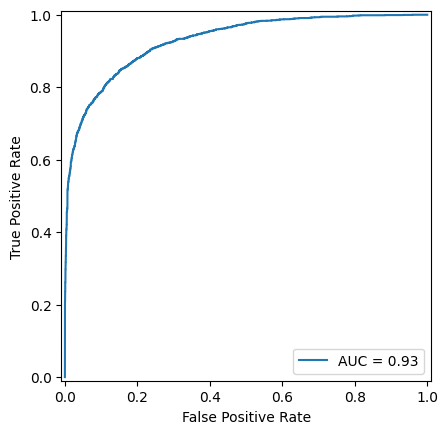

Accuracy:	0.8701159951159951
Precision:	0.8810198300283286
Recall:	0.7081056466302368
F1:	0.7851552638222671
AUC:	0.9296425088774816


In [18]:
# prepare training features (X) and target (y)
X_train_ml = X_train.drop(columns=["created_at", "description", "screen_name", "id", "location", "profile_background_image_url", "profile_image_url",
                                   "default_profile", "default_profile_image", "geo_enabled", "verified", "lang"])
y_train_ml = y_train

# initialize Random Forest model
rf = RandomForestClassifier(random_state=4222) # random_state=4222 -> reproducibility

# set up hyperparameter grid for tuning
param_grid = {
    "n_estimators": [20, 50, 100, 200, 300], # number of trees
    "max_depth": [3, 5, 7, 10], # tree complexity
    "max_features": ["sqrt", "log2", None],
    "min_samples_split": [2, 5, 10], # minimum samples to split node
    "min_samples_leaf": [1, 5, 10, 20], # minimum number of samples in leaf
    "bootstrap": [True, False]
}

# set up RandomizedSearchCV with cross-validation
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=20, # 20 random parameter combinations
    scoring='roc_auc',
    cv=5, # 5-fold cross validation
    random_state=42,
    n_jobs=-1 # use all CPU cores
)

# run RandomizedSearchCV to find best hyperparameters
random_search.fit(X_train_ml, y_train_ml)
best_model = random_search.best_estimator_

# print best parameters
print("Best Parameters:", random_search.best_params_)

# train best model on entire training data -> ensure learn from all available data
best_model.fit(X_train_ml, y_train_ml)

# prepare test features
X_test_ml = X_test.drop(columns=["created_at", "description", "screen_name", "id", "location", "profile_background_image_url", "profile_image_url",
                                 "default_profile", "default_profile_image", "geo_enabled", "verified", "lang"])
y_test_ml = y_test

# predict labels on test data
test_pred = best_model.predict(X_test_ml)

# predict probabilities on test data with the best model
test_pred_prob = best_model.predict_proba(X_test_ml)[:, 1]

# evaluate model
evaluation(y_test_ml, test_pred, test_pred_prob)

### XGBoost

*  gradient boosted decision tree model
   *   uses ensemble learning
       *   combines many small models (decision trees) into one strong model
   *   uses gradient boosting
       *   trees are built sequentially
       *   each new tree corrects the errors of previous trees
       *   uses gradient descent to minimize loss
*  strong for tabular data
*  handles nonlinear relationship well

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:32:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 1, 'n_estimators': 300, 'min_samples_leaf': 5, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:32:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


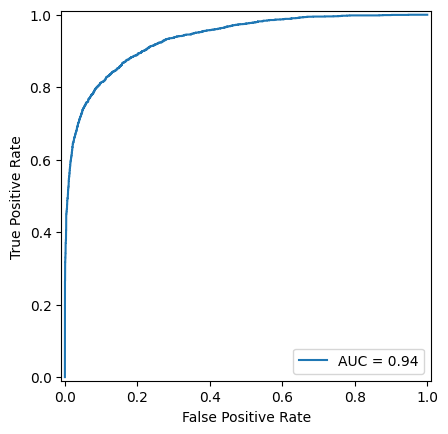

Accuracy:	0.8792735042735043
Precision:	0.8672242550967068
Recall:	0.755464480874317
F1:	0.807495741056218
AUC:	0.9354105720225938


In [ ]:
# prepare training features (X) and target (y)
X_train_ml = X_train.drop(columns=["created_at", "description", "screen_name", "id", "location", "profile_background_image_url", "profile_image_url",
                                   "default_profile", "default_profile_image", "geo_enabled", "verified", "lang"])
y_train_ml = y_train

# initialize XGBoost model
xgb = XGBClassifier(random_state=4222, enable_categorical=True) # random_state=4222 -> reproducibility, enable_categorical=True -> allow native categorical handling

# set up hyperparameter grid for tuning
param_grid = {
    "n_estimators": [100, 200, 300], # number of trees
    "learning_rate": [0.01, 0.05, 0.1, 0.2], # how fast model learns
    "max_depth": [3, 5, 7, 10], # tree complexity
    "colsample_bytree": [0.5, 0.7, 1], # feature sampling per tree
    "subsample": [0.6, 0.8, 1], # row sampling per tree
    "min_samples_leaf": [5, 10, 15, 20] # minimum number of samples in leaf
}

# set up RandomizedSearchCV with cross-validation
random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=20, # 20 random parameter combinations
    scoring='roc_auc',
    cv=5, # 5-fold cross validation
    random_state=42,
    n_jobs=-1 # use all CPU cores
)

# run RandomizedSearchCV to find best hyperparameters
random_search.fit(X_train_ml, y_train_ml)
best_model = random_search.best_estimator_

# print best parameters
print("Best Parameters:", random_search.best_params_)

# train best model on entire training data -> ensure learn from all available data
best_model.fit(X_train_ml, y_train_ml)

# prepare test features
X_test_ml = X_test.drop(columns=["created_at", "description", "screen_name", "id", "location", "profile_background_image_url", "profile_image_url",
                                 "default_profile", "default_profile_image", "geo_enabled", "verified", "lang"])
y_test_ml = y_test

# predict labels on test data
test_pred = best_model.predict(X_test_ml)

# predict probabilities on test data with the best model
test_pred_prob = best_model.predict_proba(X_test_ml)[:, 1]

# evaluate model
evaluation(y_test_ml, test_pred, test_pred_prob)

### Gradient Boosting

Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_leaf': 1, 'max_depth': 10, 'learning_rate': 0.05}


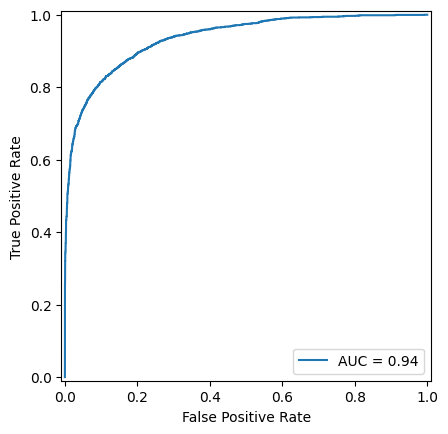

Accuracy:	0.8792735042735043
Precision:	0.8645563051375195
Recall:	0.7586520947176685
F1:	0.8081494057724957
AUC:	0.9363204825201845


In [ ]:
# prepare training features (X) and target (y)
X_train_ml = X_train.drop(columns=["created_at", "description", "screen_name", "id", "location", "profile_background_image_url", "profile_image_url",
                                   "default_profile", "default_profile_image", "geo_enabled", "verified", "lang"])
y_train_ml = y_train

# initialize Gradient Boosting model
gb = GradientBoostingClassifier(random_state=4222) # random_state=4222 -> reproducibility

# set up hyperparameter grid for tuning
param_grid = {
    "n_estimators": [100, 200, 300], # number of trees
    "learning_rate": [0.01, 0.05, 0.1, 0.2], # how fast model learns
    "max_depth": [3, 5, 7, 10], # tree complexity
    "subsample": [0.6, 0.8, 1], # row sampling per tree
    "min_samples_leaf": [1, 5, 10, 20] # minimum number of samples in leaf
}

# set up RandomizedSearchCV with cross-validation
random_search = RandomizedSearchCV(
    gb,
    param_distributions=param_grid,
    n_iter=20, # 20 random parameter combinations
    scoring='roc_auc',
    cv=5, # 5-fold cross validation
    random_state=42,
    n_jobs=-1 # use all CPU cores
)

# run RandomizedSearchCV to find best hyperparameters
random_search.fit(X_train_ml, y_train_ml)
best_model = random_search.best_estimator_

# print best parameters
print("Best Parameters:", random_search.best_params_)

# train best model on entire training data -> ensure learn from all available data
best_model.fit(X_train_ml, y_train_ml)

# prepare test features
X_test_ml = X_test.drop(columns=["created_at", "description", "screen_name", "id", "location", "profile_background_image_url", "profile_image_url",
                                 "default_profile", "default_profile_image", "geo_enabled", "verified", "lang"])
y_test_ml = y_test

# predict labels on test data
test_pred = best_model.predict(X_test_ml)

# predict probabilities on test data with the best model
test_pred_prob = best_model.predict_proba(X_test_ml)[:, 1]

# evaluate model
evaluation(y_test_ml, test_pred, test_pred_prob)

## Deep Learning Model

### Feedforward Neural Network

- best suited for tabular features
- ability to learn nonlinear relationships
- dropout layers -> randomly deactivate neurons during training -> improves generalization, prevents model from memorizing training data, reduces overfitting
- batch normalization -> stabalizes training

Suitability reasons:
- dataset consists of structured numerical features
- bot behaviour may involve complex feature interactions
- dataset may contain noisy behavioural patterns

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.7411 - auc: 0.7930 - loss: 0.5220 - val_accuracy: 0.7952 - val_auc: 0.8646 - val_loss: 0.4506
Epoch 2/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7811 - auc: 0.8451 - loss: 0.4576 - val_accuracy: 0.8125 - val_auc: 0.8766 - val_loss: 0.4302
Epoch 3/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7943 - auc: 0.8593 - loss: 0.4380 - val_accuracy: 0.8209 - val_auc: 0.8836 - val_loss: 0.4153
Epoch 4/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8020 - auc: 0.8655 - loss: 0.4288 - val_accuracy: 0.8181 - val_auc: 0.8871 - val_loss: 0.4074
Epoch 5/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8067 - auc: 0.8702 - loss: 0.4219 - val_accuracy: 0.8222 - val_auc: 0.8872 - val_loss: 0.4082
Epoch 6/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8102 - auc: 0.8741 - loss: 0.4147 - val_accuracy: 0.8227 - val_auc: 0.8889 - val_loss: 0.4089
Epoch 7/50
246/246 ━━━━━━━━━━━━━━━━━

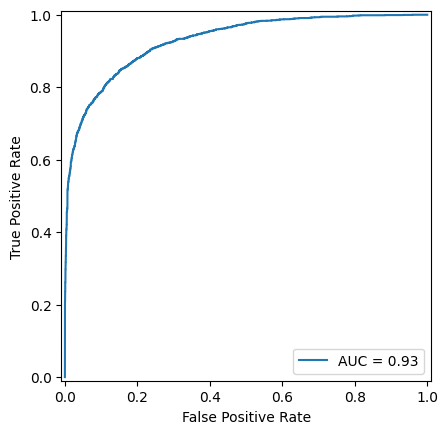

Accuracy:	0.8701159951159951
Precision:	0.8810198300283286
Recall:	0.7081056466302368
F1:	0.7851552638222671
AUC:	0.9296425088774816


In [20]:
# prepare training features (X) and target (y)
X_train_dl = X_train.drop(columns=["created_at", "description", "screen_name", "id", "location", "profile_background_image_url", "profile_image_url",
                                   "default_profile", "default_profile_image", "geo_enabled", "verified", "lang"])
y_train_dl = y_train

# feature scaling
scalar = StandardScaler()
X_train_dl = scalar.fit_transform(X_train_dl)

# build model
model = Sequential()

# input layer
model.add(Dense(128, activation='relu', input_shape=(X_train_dl.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# hidden layer 1
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# hidden layer 2
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# output layer
model.add(Dense(1, activation='sigmoid'))

# compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

# early stopping -> prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# train models
history = model.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop]
)

# prepare test features
X_test_dl = X_test.drop(columns=["created_at", "description", "screen_name", "id", "location", "profile_background_image_url", "profile_image_url",
                                 "default_profile", "default_profile_image", "geo_enabled", "verified", "lang"])
y_test_dl = y_test

X_test_dl = scalar.transform(X_test_dl)

# predict labels on test data
test_pred = best_model.predict(X_test_ml)

# predict probabilities on test data with the best model
test_pred_prob = best_model.predict_proba(X_test_ml)[:, 1]

# evaluate model
evaluation(y_test_ml, test_pred, test_pred_prob)